In [1]:
# Cell 1 — Import Libraries
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import numpy as np
from datetime import datetime

print("✅ All libraries imported successfully!")
print("   matplotlib — for drawing diagrams and charts")
print("   networkx   — for building goal tree networks")
print("   numpy      — for numerical calculations")
print("   datetime   — for timestamp on monitoring report")

✅ All libraries imported successfully!
   matplotlib — for drawing diagrams and charts
   networkx   — for building goal tree networks
   numpy      — for numerical calculations
   datetime   — for timestamp on monitoring report


In [2]:
# Cell 2 — Define Goal Types and Satisfaction Status

class GoalType:
    GOAL      = "Goal"       # Functional Requirement — binary: yes or no
    SOFTGOAL  = "Softgoal"  # Non-Functional Requirement — satisficed
    TASK      = "Task"       # Concrete action to perform
    RESOURCE  = "Resource"   # Input/output needed

class SatisfactionStatus:
    SATISFIED            = "Satisfied"
    PARTIALLY_SATISFIED  = "Partially Satisfied"
    VIOLATED             = "Violated"
    UNKNOWN              = "Unknown"

# Colours for each status
STATUS_COLORS = {
    SatisfactionStatus.SATISFIED:           "#2ECC71",  # Green
    SatisfactionStatus.PARTIALLY_SATISFIED: "#F39C12",  # Orange
    SatisfactionStatus.VIOLATED:            "#E74C3C",  # Red
    SatisfactionStatus.UNKNOWN:             "#95A5A6",  # Gray
}

# Icons for each status
STATUS_ICONS = {
    SatisfactionStatus.SATISFIED:           "✅",
    SatisfactionStatus.PARTIALLY_SATISFIED: "⚠️",
    SatisfactionStatus.VIOLATED:            "❌",
    SatisfactionStatus.UNKNOWN:             "❓",
}

print("✅ Goal types defined:")
print(f"   GoalType.GOAL      = '{GoalType.GOAL}'")
print(f"   GoalType.SOFTGOAL  = '{GoalType.SOFTGOAL}'")
print(f"   GoalType.TASK      = '{GoalType.TASK}'")
print(f"   GoalType.RESOURCE  = '{GoalType.RESOURCE}'")
print()
print("✅ Satisfaction statuses defined:")
for status, icon in STATUS_ICONS.items():
    color = STATUS_COLORS[status]
    print(f"   {icon} {status:<25} color: {color}")

✅ Goal types defined:
   GoalType.GOAL      = 'Goal'
   GoalType.SOFTGOAL  = 'Softgoal'
   GoalType.TASK      = 'Task'
   GoalType.RESOURCE  = 'Resource'

✅ Satisfaction statuses defined:
   ✅ Satisfied                 color: #2ECC71
   ⚠️ Partially Satisfied       color: #F39C12
   ❌ Violated                  color: #E74C3C
   ❓ Unknown                   color: #95A5A6


In [3]:
# Cell 3 — GoalElement and AgentModel Classes

class GoalElement:
    """
    A single element in the goal model.
    Each goal has:
    - A type (Goal, Softgoal, Task, Resource)
    - An agent who owns it
    - A parent goal (if it is a sub-goal)
    - A metric we measure
    - A threshold (what we INTEND)
    - A current value (what ACTUALLY happened)
    """
    def __init__(self, id, name, goal_type, agent,
                 parent=None, status=SatisfactionStatus.UNKNOWN,
                 metric=None, threshold=None, current_value=None):
        self.id            = id
        self.name          = name
        self.goal_type     = goal_type
        self.agent         = agent
        self.parent        = parent
        self.status        = status
        self.metric        = metric
        self.threshold     = threshold      # INTENDED value
        self.current_value = current_value  # ACTUAL value

    def evaluate(self):
        """
        THE CORE OF INTENTIONAL MONITORING:
        Compare intended behaviour (threshold)
        to actual behaviour (current_value)
        and determine satisfaction status.
        """
        if self.current_value is None or self.threshold is None:
            self.status = SatisfactionStatus.UNKNOWN

        elif self.goal_type == GoalType.SOFTGOAL:
            # NFR — satisficed, not binary
            # Good enough if within 90% of target
            ratio = self.current_value / self.threshold
            if ratio >= 0.9:
                self.status = SatisfactionStatus.SATISFIED
            elif ratio >= 0.6:
                self.status = SatisfactionStatus.PARTIALLY_SATISFIED
            else:
                self.status = SatisfactionStatus.VIOLATED

        else:
            # FR — binary evaluation
            if self.current_value >= self.threshold:
                self.status = SatisfactionStatus.SATISFIED
            elif self.current_value >= self.threshold * 0.6:
                self.status = SatisfactionStatus.PARTIALLY_SATISFIED
            else:
                self.status = SatisfactionStatus.VIOLATED

        return self.status


class AgentModel:
    """
    One agent in the agentic AI system.
    Has a name, description, colour, and list of goals.
    """
    def __init__(self, id, name, description, color):
        self.id          = id
        self.name        = name
        self.description = description
        self.color       = color
        self.goals       = []

    def add_goal(self, goal):
        self.goals.append(goal)
        return self

    def overall_status(self):
        """Overall status = worst status among all goals."""
        if not self.goals:
            return SatisfactionStatus.UNKNOWN
        statuses = [g.status for g in self.goals]
        if all(s == SatisfactionStatus.SATISFIED for s in statuses):
            return SatisfactionStatus.SATISFIED
        elif any(s == SatisfactionStatus.VIOLATED for s in statuses):
            return SatisfactionStatus.VIOLATED
        else:
            return SatisfactionStatus.PARTIALLY_SATISFIED


print("✅ GoalElement class created")
print("✅ AgentModel class created")
print()
print("The evaluate() method is the heart of intentional monitoring:")
print()

# Quick demonstration
demo = GoalElement(
    id="demo",
    name="Prioritise Urgent Cases",
    goal_type=GoalType.GOAL,
    agent="scheduling",
    metric="urgent_cases_prioritised_pct",
    threshold=100.0,
    current_value=98.0
)
result = demo.evaluate()
print(f"   Goal:          {demo.name}")
print(f"   Intended:      {demo.threshold}% urgent cases prioritised")
print(f"   Actual:        {demo.current_value}% urgent cases prioritised")
print(f"   Status:        {STATUS_ICONS[result]} {result}")
print()
print("This is intentional monitoring in action:")
print("Comparing INTENDED behaviour to ACTUAL behaviour.")

✅ GoalElement class created
✅ AgentModel class created

The evaluate() method is the heart of intentional monitoring:

   Goal:          Prioritise Urgent Cases
   Intended:      100.0% urgent cases prioritised
   Actual:        98.0% urgent cases prioritised
   Status:        ⚠️ Partially Satisfied

This is intentional monitoring in action:
Comparing INTENDED behaviour to ACTUAL behaviour.


In [4]:
# Cell 4 — Define the Agentic AI System
# Use case: Hospital Appointment Management System
# 4 agents, 17 goal elements

print("🏥 Building Agentic AI System...")
print("   Hospital Appointment Manager")
print("-" * 55)

# ── STEP 1: Create the 4 agents ──
agents = {
    "scheduling": AgentModel(
        "scheduling",
        "Scheduling Agent",
        "Manages and optimises patient appointments",
        "#3498DB"   # Blue
    ),
    "monitoring": AgentModel(
        "monitoring",
        "Monitoring Agent",
        "Verifies scheduling follows intended goals",
        "#9B59B6"   # Purple
    ),
    "communication": AgentModel(
        "communication",
        "Communication Agent",
        "Notifies patients and healthcare providers",
        "#E67E22"   # Orange
    ),
    "compliance": AgentModel(
        "compliance",
        "Compliance Agent",
        "Ensures EU AI Act and GDPR compliance",
        "#1ABC9C"   # Teal
    ),
}

print(f"✅ {len(agents)} agents created")
print()

# ── STEP 2: Define all goal elements ──
# GoalElement(id, name, type, agent, parent,
#             status, metric, threshold, current_value)

all_goals = [

    # ── SCHEDULING AGENT ──────────────────────────────
    # Main goal (FR)
    GoalElement("S1",
        "Schedule All Appointments",
        GoalType.GOAL, "scheduling", None,
        metric="appointments_scheduled_pct",
        threshold=95.0, current_value=92.0),

    # Sub-goal (FR) — must happen 100%
    GoalElement("S1a",
        "Prioritise Urgent Cases",
        GoalType.GOAL, "scheduling", "S1",
        metric="urgent_cases_prioritised_pct",
        threshold=100.0, current_value=98.0),

    # Softgoal (NFR) — quality goal, satisficed
    GoalElement("S1b",
        "Minimise Waiting Time",
        GoalType.SOFTGOAL, "scheduling", "S1",
        metric="avg_waiting_days",
        threshold=5.0, current_value=4.2),

    # Softgoal (NFR) — balance is a quality concern
    GoalElement("S1c",
        "Balance Clinician Workload",
        GoalType.SOFTGOAL, "scheduling", "S1",
        metric="workload_balance_score",
        threshold=0.8, current_value=0.61),

    # Task — concrete action
    GoalElement("S1d",
        "Retrieve Patient Records",
        GoalType.TASK, "scheduling", "S1a",
        metric="records_retrieved_pct",
        threshold=100.0, current_value=100.0),

    # ── MONITORING AGENT ──────────────────────────────
    GoalElement("M1",
        "Verify Scheduling Intentions",
        GoalType.GOAL, "monitoring", None,
        metric="intention_checks_completed_pct",
        threshold=100.0, current_value=100.0),

    GoalElement("M1a",
        "Detect Priority Violations",
        GoalType.GOAL, "monitoring", "M1",
        metric="violations_detected_pct",
        threshold=100.0, current_value=95.0),

    GoalElement("M1b",
        "Generate Monitoring Reports",
        GoalType.TASK, "monitoring", "M1",
        metric="reports_generated",
        threshold=1.0, current_value=1.0),

    # Softgoal — transparency is an NFR
    GoalElement("M1c",
        "Monitor Transparently",
        GoalType.SOFTGOAL, "monitoring", "M1",
        metric="transparency_score",
        threshold=0.9, current_value=0.88),

    # ── COMMUNICATION AGENT ───────────────────────────
    GoalElement("C1",
        "Notify All Stakeholders",
        GoalType.GOAL, "communication", None,
        metric="notifications_sent_pct",
        threshold=100.0, current_value=87.0),

    GoalElement("C1a",
        "Send Appointment Confirmations",
        GoalType.GOAL, "communication", "C1",
        metric="confirmations_sent_pct",
        threshold=100.0, current_value=91.0),

    GoalElement("C1b",
        "Send Reminders 24h Before",
        GoalType.GOAL, "communication", "C1",
        metric="reminders_on_time_pct",
        threshold=95.0, current_value=78.0),

    # Softgoal — clarity is NFR
    GoalElement("C1c",
        "Communicate Clearly",
        GoalType.SOFTGOAL, "communication", "C1",
        metric="patient_clarity_score",
        threshold=0.85, current_value=0.82),

    # ── COMPLIANCE AGENT ──────────────────────────────
    GoalElement("P1",
        "Ensure Legal Compliance",
        GoalType.GOAL, "compliance", None,
        metric="compliance_checks_passed_pct",
        threshold=100.0, current_value=100.0),

    GoalElement("P1a",
        "GDPR Data Protection",
        GoalType.GOAL, "compliance", "P1",
        metric="gdpr_violations",
        threshold=0.0, current_value=0.0),

    GoalElement("P1b",
        "EU AI Act Compliance",
        GoalType.GOAL, "compliance", "P1",
        metric="ai_act_checks_passed_pct",
        threshold=100.0, current_value=100.0),

    # Softgoal — accountability is NFR
    GoalElement("P1c",
        "Operate Accountably",
        GoalType.SOFTGOAL, "compliance", "P1",
        metric="accountability_score",
        threshold=0.95, current_value=0.96),
]

# ── STEP 3: Assign goals to agents and evaluate ──
goal_dict = {}
for g in all_goals:
    g.evaluate()                    # Run intentional monitoring
    agents[g.agent].add_goal(g)     # Assign to agent
    goal_dict[g.id] = g             # Store in dictionary

print(f"✅ {len(all_goals)} goal elements defined and evaluated")
print()

# ── STEP 4: Quick summary ──
print("AGENT SUMMARY:")
print("-" * 55)
for agent in agents.values():
    overall = agent.overall_status()
    icon = STATUS_ICONS[overall]
    goals_count = len(agent.goals)
    satisfied = sum(1 for g in agent.goals
                   if g.status == SatisfactionStatus.SATISFIED)
    print(f"{icon} {agent.name:<25} "
          f"{satisfied}/{goals_count} goals satisfied")

🏥 Building Agentic AI System...
   Hospital Appointment Manager
-------------------------------------------------------
✅ 4 agents created

✅ 17 goal elements defined and evaluated

AGENT SUMMARY:
-------------------------------------------------------
⚠️ Scheduling Agent          1/5 goals satisfied
⚠️ Monitoring Agent          3/4 goals satisfied
⚠️ Communication Agent       1/4 goals satisfied
✅ Compliance Agent          4/4 goals satisfied


In [5]:
# Cell 5 — Full Intentional Monitoring Report

print("=" * 60)
print("  INTENTIONAL MONITORING REPORT")
print(f"  Generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print("  System: Hospital Appointment Manager")
print("=" * 60)

for agent_id, agent in agents.items():
    overall = agent.overall_status()
    icon = STATUS_ICONS[overall]
    print()
    print(f"{icon} {agent.name.upper()}")
    print(f"   {agent.description}")
    print(f"   Overall: {overall}")
    print()

    for g in agent.goals:
        icon_g = STATUS_ICONS[g.status]

        # Indent sub-goals
        indent = "      " if g.parent else "   "
        type_label = f"[{g.goal_type}]"

        print(f"{indent}{icon_g} {type_label:<12} {g.name}")

        # Show the monitoring comparison
        if g.metric and g.current_value is not None:
            gap = g.current_value - g.threshold
            gap_str = f"+{gap:.1f}" if gap >= 0 else f"{gap:.1f}"
            print(f"{indent}             "
                  f"Target: {g.threshold} | "
                  f"Actual: {g.current_value} | "
                  f"Gap: {gap_str}")
    print()
    print("-" * 60)

# Overall system assessment
print()
print("SYSTEM-LEVEL INTENTIONAL ASSESSMENT:")
print("=" * 60)
total = len(all_goals)
sat   = sum(1 for g in all_goals
            if g.status == SatisfactionStatus.SATISFIED)
part  = sum(1 for g in all_goals
            if g.status == SatisfactionStatus.PARTIALLY_SATISFIED)
viol  = sum(1 for g in all_goals
            if g.status == SatisfactionStatus.VIOLATED)

print(f"   ✅ Satisfied:           {sat}/{total} goals")
print(f"   ⚠️  Partially Satisfied: {part}/{total} goals")
print(f"   ❌ Violated:            {viol}/{total} goals")
print()
print("   CRITICAL FINDING:")
print("   The agentic AI system is technically operational")
print("   but NOT fully acting according to its stated intentions.")
print("   Intentional monitoring reveals hidden goal violations")
print("   that would be invisible without this framework.")
print("=" * 60)

  INTENTIONAL MONITORING REPORT
  Generated: 2026-05-29 14:19
  System: Hospital Appointment Manager

⚠️ SCHEDULING AGENT
   Manages and optimises patient appointments
   Overall: Partially Satisfied

   ⚠️ [Goal]       Schedule All Appointments
                Target: 95.0 | Actual: 92.0 | Gap: -3.0
      ⚠️ [Goal]       Prioritise Urgent Cases
                   Target: 100.0 | Actual: 98.0 | Gap: -2.0
      ⚠️ [Softgoal]   Minimise Waiting Time
                   Target: 5.0 | Actual: 4.2 | Gap: -0.8
      ⚠️ [Softgoal]   Balance Clinician Workload
                   Target: 0.8 | Actual: 0.61 | Gap: -0.2
      ✅ [Task]       Retrieve Patient Records
                   Target: 100.0 | Actual: 100.0 | Gap: +0.0

------------------------------------------------------------

⚠️ MONITORING AGENT
   Verifies scheduling follows intended goals
   Overall: Partially Satisfied

   ✅ [Goal]       Verify Scheduling Intentions
                Target: 100.0 | Actual: 100.0 | Gap: +0.0
      ⚠️ [

In [7]:
# Fix — Install Graphviz for proper tree layout
import subprocess
subprocess.run(['apt-get', 'install', '-y', 'graphviz'],
               capture_output=True)
!pip install pygraphviz --quiet

print("✅ Graphviz installed — re-run Cell 6 for proper tree layout")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.0/106.0 kB 3.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  error: subprocess-exited-with-error
  
  × Building wheel for pygraphviz (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for pygraphviz
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (pygraphviz)
✅ Graphviz installed — re-run Cell 6 for proper tree layout


/tmp/ipykernel_3735/1885577168.py:123: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.07, 1, 0.96])
/tmp/ipykernel_3735/1885577168.py:124: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('GoalModel_AgenticAI.png',
/tmp/ipykernel_3735/1885577168.py:124: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('GoalModel_AgenticAI.png',
/tmp/ipykernel_3735/1885577168.py:124: UserWarning: Glyph 10067 (\N{BLACK QUESTION MARK ORNAMENT}) missing from font(s) DejaVu Sans.
  plt.savefig('GoalModel_AgenticAI.png',


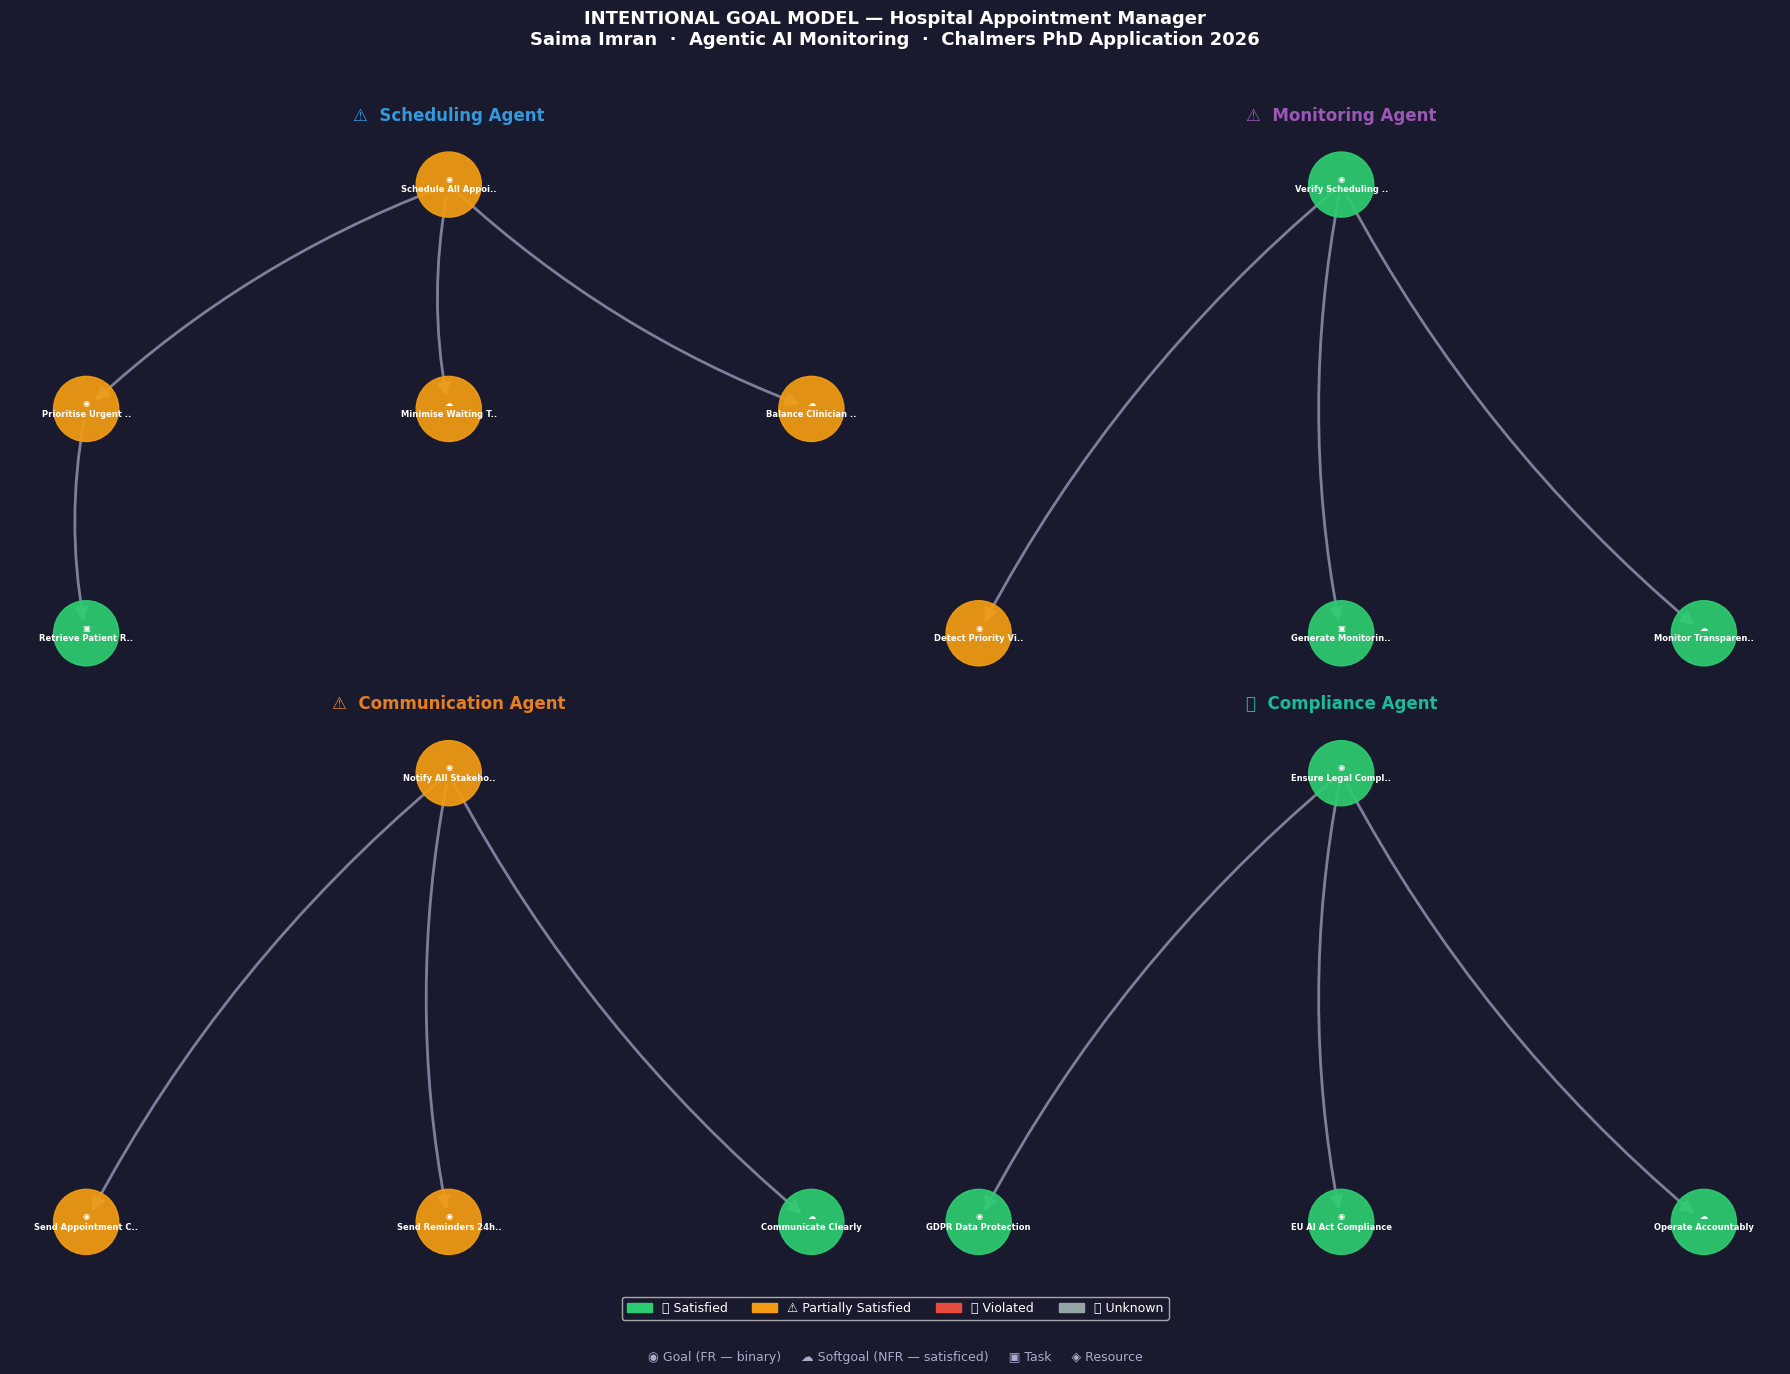


✅ Goal model diagram saved!
   Each box = one goal element
   Lines show parent → child relationships
   Colours show satisfaction status


In [9]:
# Cell 6 — Improved Goal Tree (no Graphviz needed)

def make_tree_layout(G):
    """Build a clean top-down tree layout manually."""
    pos = {}
    # Find root nodes (no incoming edges)
    roots = [n for n in G.nodes() if G.in_degree(n) == 0]
    if not roots:
        return nx.spring_layout(G, seed=42)

    def assign_pos(node, x, y, x_gap):
        pos[node] = (x, y)
        children = list(G.successors(node))
        if not children:
            return
        total_width = (len(children) - 1) * x_gap
        start_x = x - total_width / 2
        for i, child in enumerate(children):
            assign_pos(child, start_x + i * x_gap, y - 1.8, x_gap * 0.6)

    assign_pos(roots[0], 0, 0, 3.0)
    return pos

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.patch.set_facecolor('#1A1A2E')
fig.suptitle(
    'INTENTIONAL GOAL MODEL — Hospital Appointment Manager\n'
    'Saima Imran  ·  Agentic AI Monitoring  ·  Chalmers PhD Application 2026',
    color='white', fontsize=13, fontweight='bold', y=0.98
)

agent_list   = list(agents.values())
agent_colors = ["#3498DB", "#9B59B6", "#E67E22", "#1ABC9C"]
ax_positions = [(0,0), (0,1), (1,0), (1,1)]

for idx, (agent, color) in enumerate(zip(agent_list, agent_colors)):
    row, col = ax_positions[idx]
    ax = axes[row][col]
    ax.set_facecolor('#16213E')

    G = nx.DiGraph()
    labels   = {}
    colors_n = []

    for g in agent.goals:
        short = (g.name[:18] + "..") if len(g.name) > 20 else g.name
        type_icon = {
            "Goal":     "◉",
            "Softgoal": "☁",
            "Task":     "▣",
            "Resource": "◈"
        }
        label = f"{type_icon.get(g.goal_type,'○')}\n{short}"
        G.add_node(g.id, label=label)
        labels[g.id] = label
        colors_n.append(STATUS_COLORS[g.status])

    for g in agent.goals:
        if g.parent and g.parent in [x.id for x in agent.goals]:
            G.add_edge(g.parent, g.id)

    # Use our custom tree layout
    pos = make_tree_layout(G)

    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_color=colors_n,
        node_size=2200,
        alpha=0.92
    )
    nx.draw_networkx_edges(
        G, pos, ax=ax,
        edge_color='#AAAACC',
        arrows=True,
        arrowsize=20,
        width=2,
        alpha=0.7,
        connectionstyle='arc3,rad=0.1'
    )
    nx.draw_networkx_labels(
        G, pos, labels, ax=ax,
        font_size=6,
        font_color='white',
        font_weight='bold'
    )

    overall      = agent.overall_status()
    overall_icon = STATUS_ICONS[overall]
    ax.set_title(
        f"{overall_icon}  {agent.name}",
        fontsize=12, fontweight='bold',
        color=color, pad=12
    )
    ax.axis('off')

# Bottom legend — goal types
fig.text(
    0.5, 0.015,
    '◉ Goal (FR — binary)     '
    '☁ Softgoal (NFR — satisficed)     '
    '▣ Task     ◈ Resource',
    ha='center', fontsize=9, color='#AAAACC'
)

# Colour legend
legend_elements = [
    mpatches.Patch(color="#2ECC71", label="✅ Satisfied"),
    mpatches.Patch(color="#F39C12", label="⚠️ Partially Satisfied"),
    mpatches.Patch(color="#E74C3C", label="❌ Violated"),
    mpatches.Patch(color="#95A5A6", label="❓ Unknown"),
]
fig.legend(
    handles=legend_elements,
    loc='lower center',
    ncol=4,
    bbox_to_anchor=(0.5, 0.04),
    facecolor='#1A1A2E',
    labelcolor='white',
    fontsize=9,
    framealpha=0.8
)

plt.tight_layout(rect=[0, 0.07, 1, 0.96])
plt.savefig('GoalModel_AgenticAI.png',
            dpi=150, bbox_inches='tight',
            facecolor='#1A1A2E')
plt.show()
print()
print("✅ Goal model diagram saved!")
print("   Each box = one goal element")
print("   Lines show parent → child relationships")
print("   Colours show satisfaction status")

/tmp/ipykernel_3735/248605979.py:106: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3735/248605979.py:106: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3735/248605979.py:107: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('MonitoringDashboard_AgenticAI.png',
/tmp/ipykernel_3735/248605979.py:107: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('MonitoringDashboard_AgenticAI.png',
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(byt

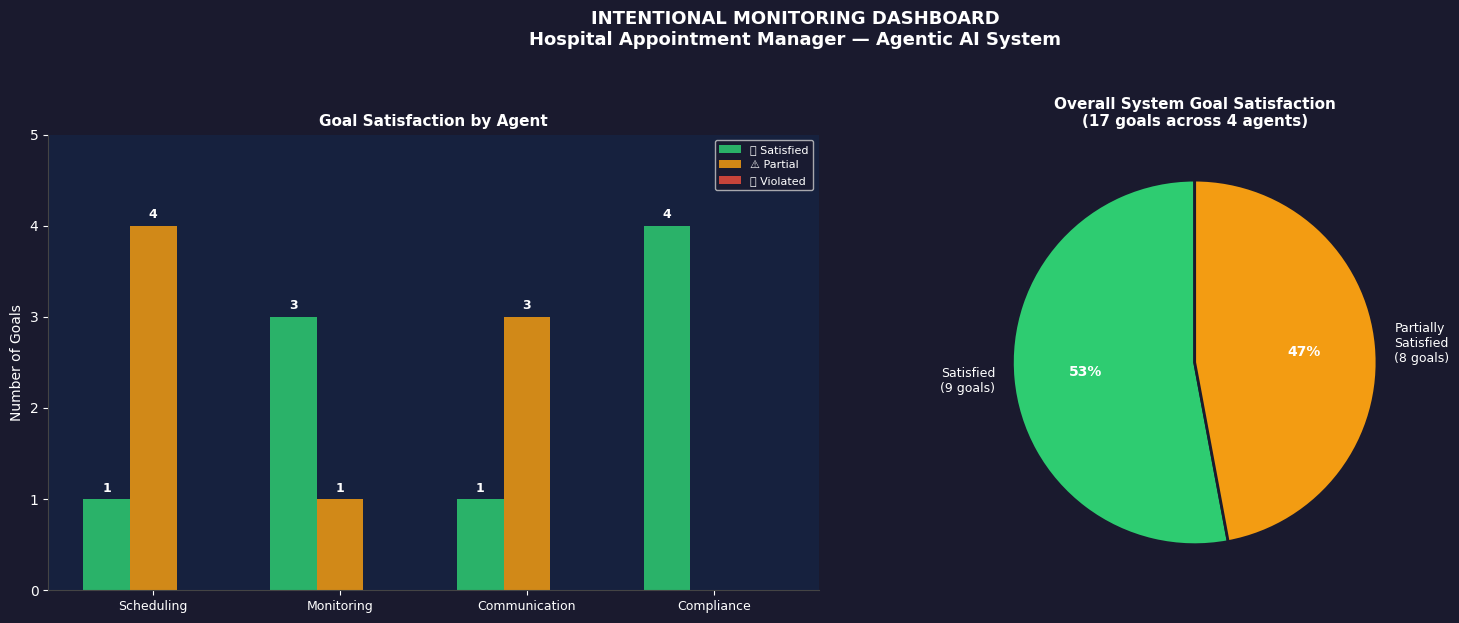


✅ Dashboard saved as 'MonitoringDashboard_AgenticAI.png'

LEFT CHART — shows each agent's goal satisfaction breakdown
RIGHT CHART — shows overall system satisfaction as percentage

Key insight from dashboard:
  9 goals fully satisfied
  8 goals partially satisfied
  The system APPEARS operational but intentions
  are only PARTIALLY being followed.


In [10]:
# Cell 7 — Monitoring Dashboard

fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6))
fig2.patch.set_facecolor('#1A1A2E')

# ── Chart 1: Goal satisfaction by agent (bar chart) ──
ax1 = axes2[0]
ax1.set_facecolor('#16213E')

agent_names = [a.name.replace(" Agent","") for a in agents.values()]
satisfied   = []
partial     = []
violated    = []

for agent in agents.values():
    s = sum(1 for g in agent.goals
            if g.status == SatisfactionStatus.SATISFIED)
    p = sum(1 for g in agent.goals
            if g.status == SatisfactionStatus.PARTIALLY_SATISFIED)
    v = sum(1 for g in agent.goals
            if g.status == SatisfactionStatus.VIOLATED)
    satisfied.append(s)
    partial.append(p)
    violated.append(v)

x = np.arange(len(agent_names))
w = 0.25

bars1 = ax1.bar(x - w, satisfied, w,
                label='✅ Satisfied',
                color='#2ECC71', alpha=0.85)
bars2 = ax1.bar(x,     partial,   w,
                label='⚠️ Partial',
                color='#F39C12', alpha=0.85)
bars3 = ax1.bar(x + w, violated,  w,
                label='❌ Violated',
                color='#E74C3C', alpha=0.85)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax1.text(
                bar.get_x() + bar.get_width()/2,
                h + 0.05, str(int(h)),
                ha='center', va='bottom',
                color='white', fontsize=9,
                fontweight='bold'
            )

ax1.set_xticks(x)
ax1.set_xticklabels(agent_names, color='white', fontsize=9)
ax1.set_ylabel('Number of Goals', color='white', fontsize=10)
ax1.set_title('Goal Satisfaction by Agent',
              color='white', fontweight='bold', fontsize=11)
ax1.tick_params(colors='white')
ax1.legend(facecolor='#1A1A2E', labelcolor='white', fontsize=8)
ax1.spines['bottom'].set_color('#444')
ax1.spines['left'].set_color('#444')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.yaxis.label.set_color('white')
ax1.set_ylim(0, max(max(satisfied), max(partial)) + 1)

# ── Chart 2: Overall system pie chart ──
ax2 = axes2[1]
ax2.set_facecolor('#16213E')

all_statuses = [g.status for g in all_goals]
counts = {
    'Satisfied':           all_statuses.count(SatisfactionStatus.SATISFIED),
    'Partially\nSatisfied': all_statuses.count(SatisfactionStatus.PARTIALLY_SATISFIED),
    'Violated':            all_statuses.count(SatisfactionStatus.VIOLATED),
}

sizes_pie  = [v for v in counts.values() if v > 0]
labels_pie = [f"{k}\n({v} goals)" for k,v in counts.items() if v > 0]
colors_pie = ['#2ECC71', '#F39C12', '#E74C3C'][:len(sizes_pie)]

wedges, texts, autotexts = ax2.pie(
    sizes_pie,
    labels=labels_pie,
    colors=colors_pie,
    autopct='%1.0f%%',
    startangle=90,
    textprops={'color': 'white', 'fontsize': 9},
    wedgeprops={'edgecolor': '#1A1A2E', 'linewidth': 2}
)
for at in autotexts:
    at.set_color('white')
    at.set_fontweight('bold')
    at.set_fontsize(10)

ax2.set_title('Overall System Goal Satisfaction\n(17 goals across 4 agents)',
              color='white', fontweight='bold', fontsize=11)

# ── Main title ──
fig2.suptitle(
    'INTENTIONAL MONITORING DASHBOARD\n'
    'Hospital Appointment Manager — Agentic AI System',
    color='white', fontsize=13,
    fontweight='bold', y=1.03
)

plt.tight_layout()
plt.savefig('MonitoringDashboard_AgenticAI.png',
            dpi=150, bbox_inches='tight',
            facecolor='#1A1A2E')
plt.show()

print()
print("✅ Dashboard saved as 'MonitoringDashboard_AgenticAI.png'")
print()
print("LEFT CHART — shows each agent's goal satisfaction breakdown")
print("RIGHT CHART — shows overall system satisfaction as percentage")
print()
print("Key insight from dashboard:")
print(f"  {counts['Satisfied']} goals fully satisfied")
print(f"  {counts['Partially'+chr(10)+'Satisfied']} goals partially satisfied")
print("  The system APPEARS operational but intentions")
print("  are only PARTIALLY being followed.")

In [11]:
# Cell 8 — Research Insights and Conclusions

print()
print("=" * 60)
print("  RESEARCH INSIGHTS")
print("  Goal Model Visualiser for Agentic AI Systems")
print("  Saima Imran — Chalmers PhD Application 2026")
print("=" * 60)
print()
print("CONCEPT 1 — GOAL EXPLICITNESS")
print("-" * 60)
print("Every agent's intentions are made explicit in the model.")
print("Goals, sub-goals, tasks and softgoals are defined")
print("BEFORE the system runs — not discovered after failure.")
print()
print("CONCEPT 2 — FR vs NFR (GOAL vs SOFTGOAL)")
print("-" * 60)
print("Hard Goals (FRs) — binary evaluation:")
print("  'Schedule all appointments' → done or not done")
print()
print("Softgoals (NFRs) — satisficed evaluation:")
print("  'Minimise waiting time' → how well? 60%? 80%? 95%?")
print("  NFRs cannot be fully satisfied — only satisficed.")
print("  This is the iStar framework distinction.")
print()
print("CONCEPT 3 — INTENTIONAL MONITORING")
print("-" * 60)
print("For every goal the system compares:")
print("  INTENDED behaviour → threshold (design specification)")
print("  ACTUAL behaviour   → current_value (observed reality)")
print("  GAP                → deviation from intention")
print()
print("Biggest gaps found in this system:")
print()

# Find and sort biggest gaps
gaps = []
for g in all_goals:
    if g.threshold and g.current_value is not None:
        if g.goal_type == GoalType.SOFTGOAL:
            gap = (g.current_value/g.threshold - 1) * 100
        else:
            gap = g.current_value - g.threshold
        gaps.append((gap, g))

gaps.sort(key=lambda x: x[0])

for gap_val, g in gaps[:5]:
    icon = STATUS_ICONS[g.status]
    print(f"  {icon} {g.name}")
    print(f"     Intended: {g.threshold} | "
          f"Actual: {g.current_value} | "
          f"Gap: {gap_val:.1f}")
    print()

print()
print("CONCEPT 4 — VISUALISATION FOR OBSERVABILITY")
print("-" * 60)
print("Goal trees make agent intentions VISIBLE.")
print("Human overseers can see at a glance:")
print("  → Which agents are following their intentions ✅")
print("  → Which agents are drifting from intentions ⚠️")
print("  → Which goals need immediate attention ❌")
print()
print("This satisfies EU AI Act Article 13 — Transparency")
print("and Article 14 — Human Oversight requirements")
print("for high-risk AI systems.")
print()
print("=" * 60)
print("  LIMITATIONS & FUTURE WORK")
print("=" * 60)
print()
print("This prototype demonstrates the concept but:")
print("  → Goal models are manually defined")
print("     Future: auto-generate from AI system specs")
print()
print("  → Monitoring uses simulated values")
print("     Future: connect to real agentic AI systems")
print()
print("  → Single-level goal decomposition")
print("     Future: multi-level hierarchical goal models")
print()
print("  → No conflict detection between agent goals")
print("     Future: detect when agent intentions conflict")
print()
print("These limitations define the PhD research agenda:")
print("How to build AUTOMATED, SCALABLE, FORMAL")
print("intentional monitoring for complex agentic AI systems.")
print()
print("=" * 60)
print("  github.com/saima-imran")
print("  Saima Imran | Gothenburg, Sweden | May 2026")
print("=" * 60)


  RESEARCH INSIGHTS
  Goal Model Visualiser for Agentic AI Systems
  Saima Imran — Chalmers PhD Application 2026

CONCEPT 1 — GOAL EXPLICITNESS
------------------------------------------------------------
Every agent's intentions are made explicit in the model.
Goals, sub-goals, tasks and softgoals are defined
BEFORE the system runs — not discovered after failure.

CONCEPT 2 — FR vs NFR (GOAL vs SOFTGOAL)
------------------------------------------------------------
Hard Goals (FRs) — binary evaluation:
  'Schedule all appointments' → done or not done

Softgoals (NFRs) — satisficed evaluation:
  'Minimise waiting time' → how well? 60%? 80%? 95%?
  NFRs cannot be fully satisfied — only satisficed.
  This is the iStar framework distinction.

CONCEPT 3 — INTENTIONAL MONITORING
------------------------------------------------------------
For every goal the system compares:
  INTENDED behaviour → threshold (design specification)
  ACTUAL behaviour   → current_value (observed reality)
  GAP 